**Task 3: Heart Disease Prediction**

Submitted by: Naima Imtiaz


Dataset Shape: (303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4

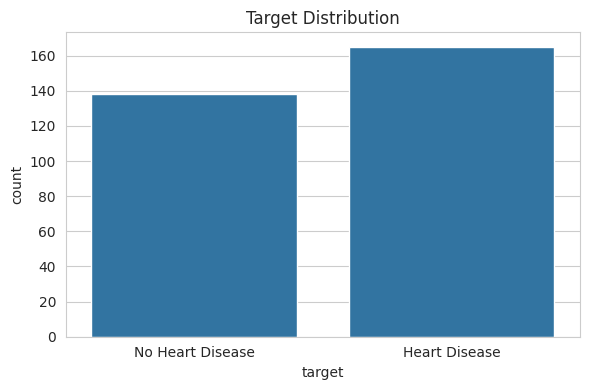


Target Percentage Distribution:
target
1    54.46
0    45.54
Name: proportion, dtype: float64


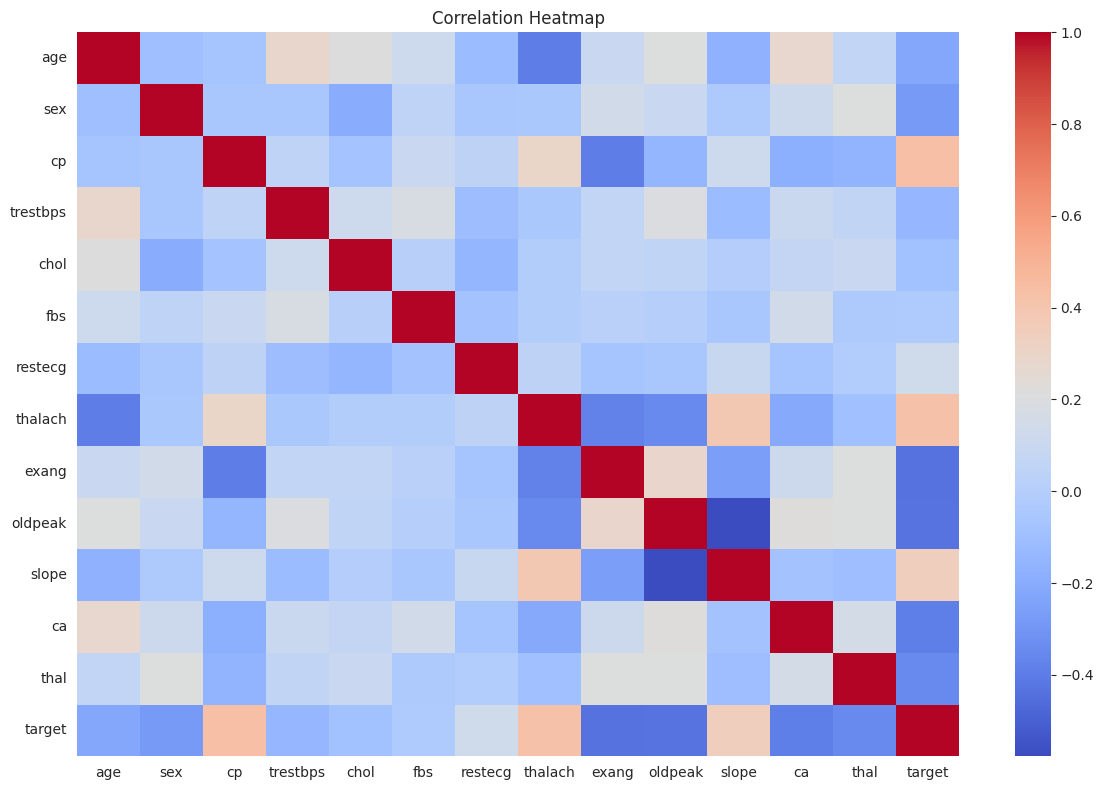

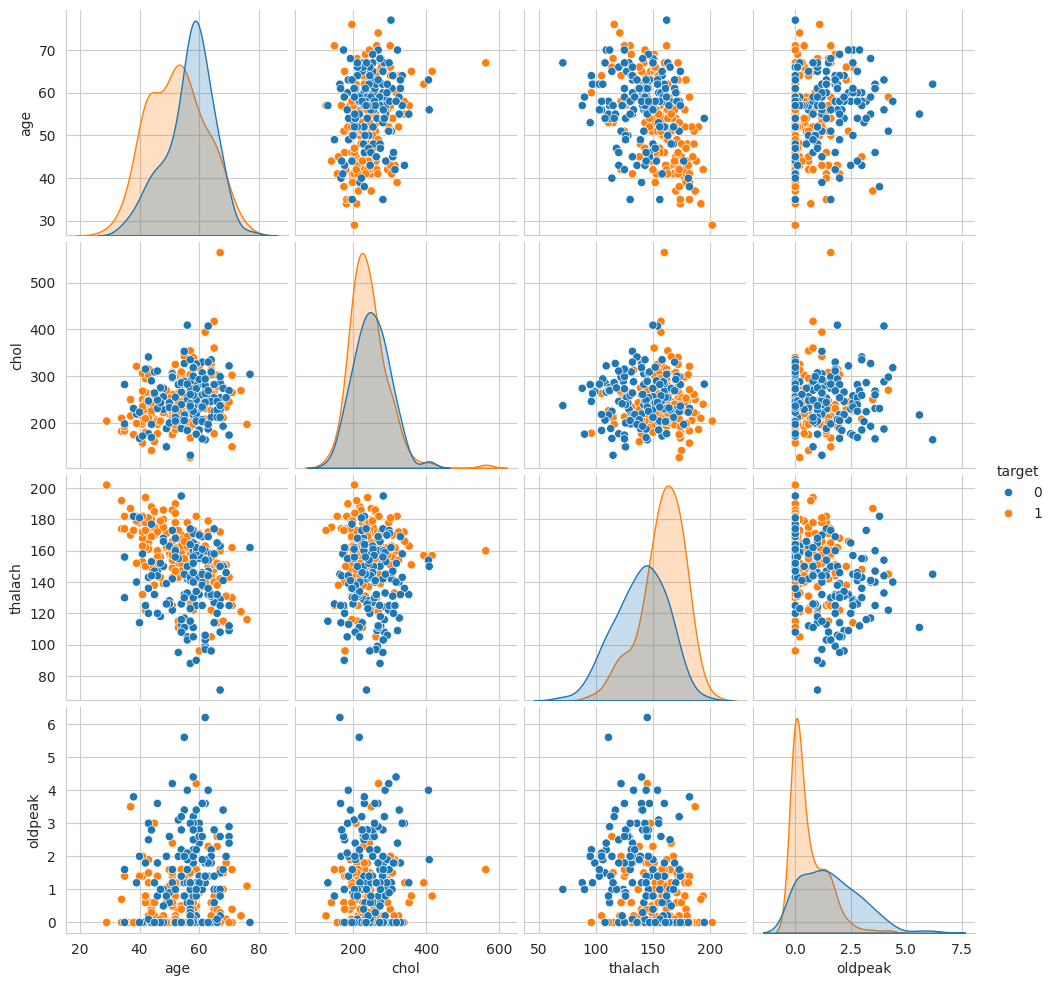

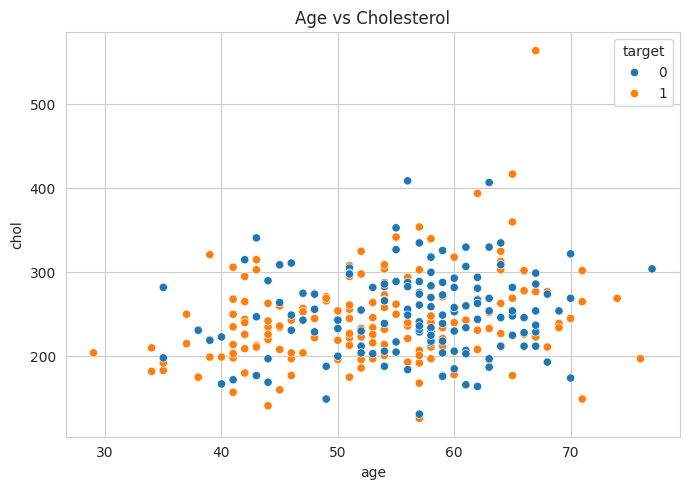


Logistic Regression Accuracy: 80.33 %
Logistic Regression ROC-AUC: 0.869

Decision Tree Accuracy: 78.69 %
Decision Tree ROC-AUC: 0.8176


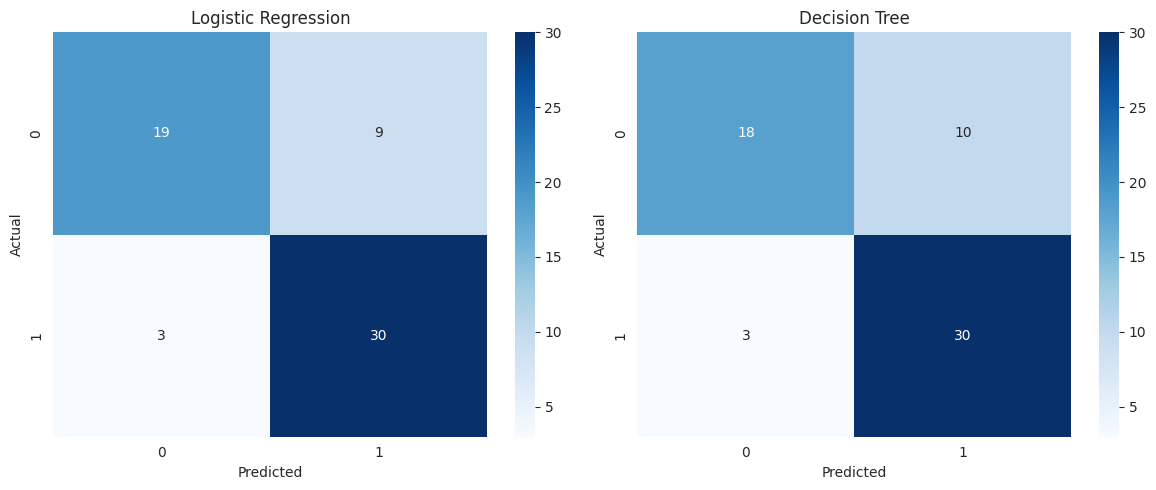

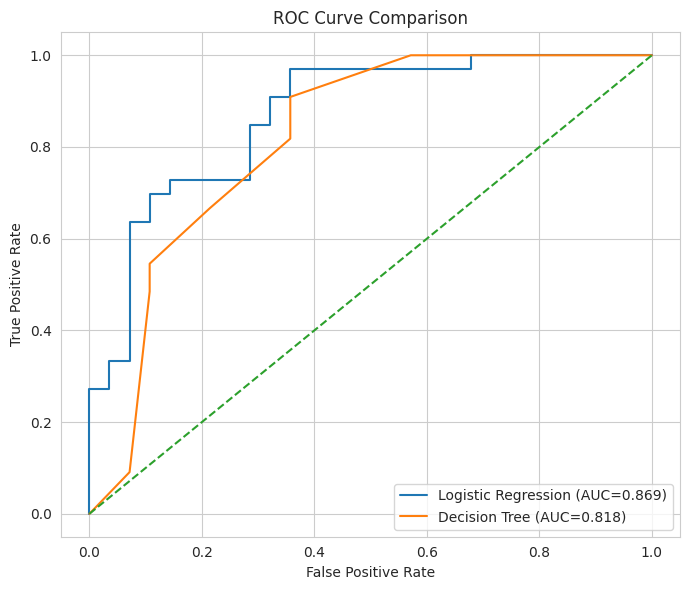

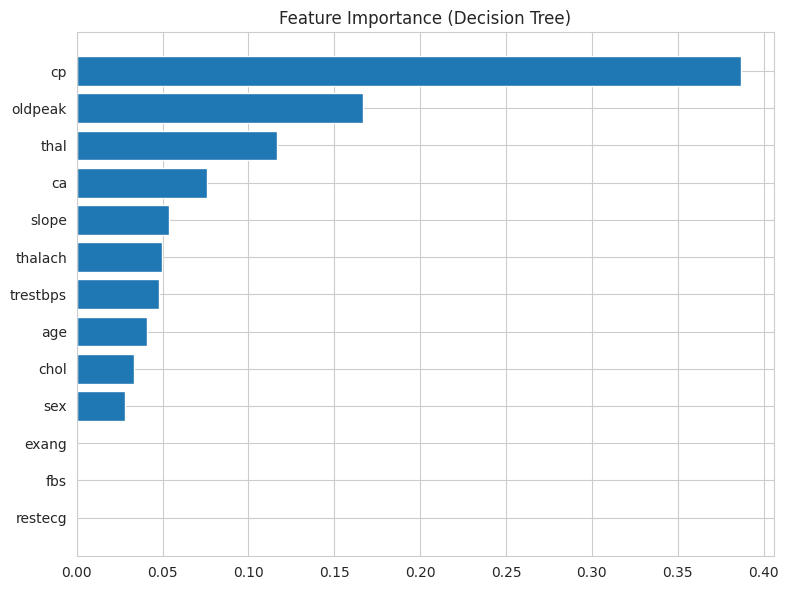

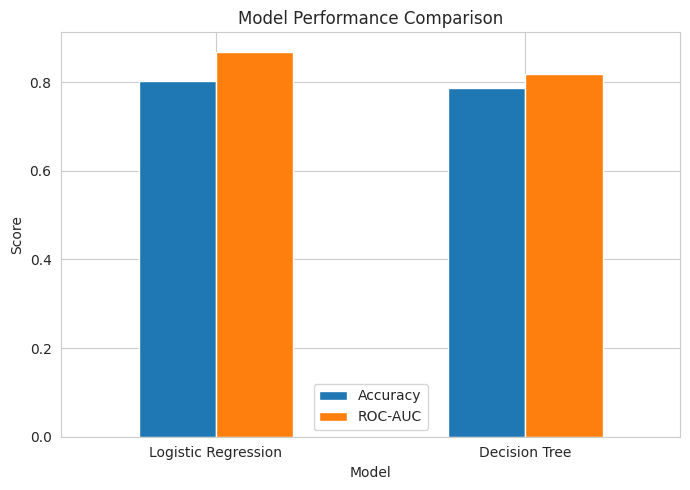


Best Model Based on ROC-AUC: Logistic Regression


In [5]:
"""
Goal:
Predict whether a patient is at risk of heart disease using classification models.
Models:
- Logistic Regression
- Decision Tree
Evaluation:
Accuracy, ROC-AUC, Confusion Matrix, ROC Curve, Feature Importance
"""

# Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

sns.set_style("whitegrid")

# Load Dataset

url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print(df.head())

# Data Inspection


print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

if df.isnull().sum().sum() > 0:
    df.fillna(df.median(numeric_only=True), inplace=True)

# Exploratory Data Analysis


# Target Distribution (Count + Percentage)
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"])
plt.tight_layout()
plt.show()

target_percentage = df["target"].value_counts(normalize=True) * 100
print("\nTarget Percentage Distribution:")
print(target_percentage.round(2))


# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# Pairplot for Key Features
key_features = ["age", "chol", "thalach", "oldpeak", "target"]
sns.pairplot(df[key_features], hue="target")
plt.show()


# Age vs Cholesterol Scatter
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="age", y="chol", hue="target")
plt.title("Age vs Cholesterol")
plt.tight_layout()
plt.show()

# Prepare Data


X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

# Decision Tree


dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

dt_acc = accuracy_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)

# Model Evaluation

print("\nLogistic Regression Accuracy:", round(lr_acc * 100, 2), "%")
print("Logistic Regression ROC-AUC:", round(lr_auc, 4))

print("\nDecision Tree Accuracy:", round(dt_acc * 100, 2), "%")
print("Decision Tree ROC-AUC:", round(dt_auc, 4))


# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(
    axes,
    [lr_pred, dt_pred],
    ["Logistic Regression", "Decision Tree"]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


# ROC Curve Comparison
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

plt.figure(figsize=(7, 6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC={lr_auc:.3f})")
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC={dt_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance (Decision Tree)")
plt.tight_layout()
plt.show()

# Model Comparison Visualization


metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [lr_acc, dt_acc],
    "ROC-AUC": [lr_auc, dt_auc]
})

metrics_df.set_index("Model").plot(kind="bar", figsize=(7, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Final Summary

best_model = "Logistic Regression" if lr_auc >= dt_auc else "Decision Tree"

print("\nBest Model Based on ROC-AUC:", best_model)

The executed code performs a heart disease prediction task using two classification models: Logistic Regression and Decision Tree. Here's a breakdown of the process:

1.  **Objective**: The goal is to predict whether a patient is at risk of heart disease (`target` variable) using various health metrics.

2.  **Import Libraries**: Essential libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib.pyplot`, `seaborn`), model building (`sklearn.model_selection`, `sklearn.preprocessing`, `sklearn.linear_model`, `sklearn.tree`), and model evaluation (`sklearn.metrics`) are imported.

3.  **Load Dataset**: The `heart_disease.csv` dataset is loaded from a URL into a pandas DataFrame. The shape of the dataset and its first few rows are printed.

4.  **Data Inspection**: The code checks for basic information about the dataset:
    *   `df.info()`: Provides data types and non-null counts for each column.
    *   `df.isnull().sum()`: Detects and prints the count of missing values per column.
    *   Missing values (if any) are imputed using the median of their respective columns.

5.  **Exploratory Data Analysis (EDA)**:
    *   **Target Distribution**: A count plot shows the distribution of the `target` variable (heart disease vs. no heart disease), along with its percentage distribution.
    *   **Correlation Heatmap**: A heatmap visualizes the correlation matrix of all features, helping to understand relationships between variables.
    *   **Pairplot**: A pairplot for key features (`age`, `chol`, `thalach`, `oldpeak`, `target`) is generated to show relationships and distributions within and between these features, grouped by the `target`.
    *   **Age vs. Cholesterol Scatter Plot**: A scatter plot illustrates the relationship between `age` and `cholesterol`, colored by the `target` variable.

6.  **Prepare Data**:
    *   The dataset is split into features (`X`, by dropping the `target` column) and the target variable (`y`).
    *   The data is then split into training (80%) and testing (20%) sets using `train_test_split`, ensuring stratification to maintain the proportion of target classes in both sets.

7.  **Feature Scaling**: `StandardScaler` is used to scale numerical features in the training and testing sets. This is crucial for models like Logistic Regression, which are sensitive to feature scales.

8.  **Model Training**:
    *   **Logistic Regression**: A `LogisticRegression` model is initialized and trained on the scaled training data. Predictions (`lr_pred`) and probability scores (`lr_prob`) are generated for the test set.
    *   **Decision Tree**: A `DecisionTreeClassifier` model is initialized (with a `max_depth` of 5) and trained on the original (unscaled) training data. Predictions (`dt_pred`) and probability scores (`dt_prob`) are generated for the test set.

9.  **Model Evaluation**:
    *   **Accuracy and ROC-AUC**: The accuracy score and ROC-AUC score are calculated and printed for both Logistic Regression and Decision Tree models.
    *   **Confusion Matrices**: Two heatmaps display the confusion matrices for both models, showing true positives, true negatives, false positives, and false negatives.
    *   **ROC Curve Comparison**: An ROC curve plot compares the performance of both models by showing their True Positive Rate (TPR) against their False Positive Rate (FPR) at various threshold settings. The AUC (Area Under the Curve) is also displayed.

10. **Feature Importance (Decision Tree)**: A horizontal bar chart visualizes the importance of each feature as determined by the Decision Tree model, highlighting which features contribute most to its predictions.

11. **Model Comparison Visualization**: A bar chart compares the Accuracy and ROC-AUC scores of Logistic Regression and Decision Tree models side-by-side.

12. **Final Summary**: The model with the higher ROC-AUC score is identified and printed as the 'Best Model'.